In [3]:
import pandas as pd
import linearmodels as lm

data = pd.read_csv('ITSUR_data.csv')
data.describe()

,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW),solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15,NP15 Solar Generation (MW),SP15 Solar Generation (MW),NP15 Wind Generation (MW),SP15 Wind Generation (MW)
count,31632.000000,31632.000000,30935.000000,30914.000000,33384.000000,33371.000000,33368.000000,31151.000000,31151.000000,31628.000000,31628.000000,33384.000000,33384.000000,33384.000000,33384.000000,31820.000000,31820.000000,31820.000000,31821.000000
mean,61.854099,56.897117,56.256998,48.861142,3.772176,13568.353361,19172.373109,11462.250522,11794.551828,11055.699087,11260.804769,622.121147,451.034260,3356.805968,1337.945629,516.019988,3003.447081,438.327869,1257.844808
std,53.188503,55.939227,62.478070,58.767666,2.063652,17255.895886,16749.017814,2012.520260,2647.434579,2150.912595,2620.052590,753.123066,342.802924,4025.648343,1021.382395,634.814762,3682.156658,373.296451,1014.535598
min,-31.707580,-67.082140,-73.952840,-157.098370,1.210000,1940.000000,-5360.000000,5804.000000,6898.000000,4988.950000,5519.250000,0.000000,2.280000,0.000000,14.310000,-307.909700,-93.474700,-20.167350,-31.577960
25%,36.659480,31.089572,31.903595,25.723788,2.330000,3110.000000,9390.000000,10089.000000,9953.000000,9613.207500,9516.367500,0.000000,132.070000,0.000000,383.667500,-3.460348,-28.790920,93.062130,304.305330
50%,51.467660,48.033120,46.648480,42.775840,2.880000,7150.000000,14000.000000,11152.000000,11143.000000,10764.515000,10620.385000,42.840000,380.475000,280.965000,1145.710000,42.711880,213.041785,337.555405,1050.853010
75%,72.290310,69.600523,65.743765,61.250870,4.900000,15800.000000,21900.000000,12346.000000,12705.500000,12036.227500,12021.865000,1403.800000,745.182500,7373.170000,2186.632500,1140.976028,6519.527327,757.419970,2094.696690
max,1262.849100,1300.110000,1992.543500,1870.605200,13.200000,189000.000000,87500.000000,22371.000000,25394.000000,22599.960000,25226.770000,2091.380000,1298.770000,12716.770000,3785.210000,1925.043940,12570.905160,2252.736830,3891.374970


In [4]:
data

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW),solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15,NP15 Solar Generation (MW),SP15 Solar Generation (MW),NP15 Wind Generation (MW),SP15 Wind Generation (MW)
0,2021-03-12 00:00:00,42.96548,40.78043,34.56084,33.48478,2.65,11900.0,14800.0,9914.0,9763.0,10102.72,9686.47,0.0,327.97,0.0,1062.94,-2.69832,-26.29464,526.78168,713.36328
1,2021-03-12 01:00:00,39.48897,37.76416,33.10504,32.01413,2.65,11900.0,14400.0,9827.0,9536.0,9868.57,9474.64,0.0,259.94,0.0,1018.10,-2.66009,-26.30124,405.97186,583.05445
2,2021-03-12 02:00:00,39.09879,37.50715,34.53900,33.43611,2.65,11900.0,12500.0,9849.0,9416.0,9712.50,9339.19,0.0,191.44,0.0,974.17,-2.68074,-26.46864,288.43194,730.31104
3,2021-03-12 03:00:00,39.38309,37.79894,33.62841,32.36996,2.65,11900.0,8930.0,9939.0,9475.0,9715.76,9304.25,0.0,148.07,0.0,935.87,-2.68692,-29.03769,205.85381,709.88240
4,2021-03-12 04:00:00,41.92228,40.13255,34.56917,33.48674,2.65,11800.0,6770.0,10287.0,9842.0,9969.51,9545.95,0.0,134.36,0.0,908.84,-2.58009,-29.40176,173.78675,661.02222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33379,2024-12-31 19:00:00,52.95726,51.32403,47.43169,46.97551,3.40,84500.0,54300.0,11307.0,10952.0,11959.79,10989.78,0.0,48.25,0.0,455.97,-3.03842,-37.67855,58.35641,29.42005
33380,2024-12-31 20:00:00,52.41941,51.57697,46.46807,45.63533,3.40,83100.0,54900.0,10967.0,10667.0,11723.02,10760.92,0.0,55.64,0.0,443.61,-7.19792,-37.10158,65.56839,32.46489
33381,2024-12-31 21:00:00,52.23158,50.44737,44.37653,43.81899,3.40,81900.0,54600.0,10614.0,10503.0,11408.80,10646.09,0.0,65.90,0.0,427.09,-6.79170,-37.17194,62.77812,27.18265
33382,2024-12-31 22:00:00,51.55114,50.00000,46.56593,45.68607,3.40,81100.0,55000.0,10226.0,10237.0,10831.46,10435.11,0.0,77.46,0.0,344.13,-6.26466,-37.52891,54.79276,39.90553


In [ ]:
model = SUR.from_formula(equations, df)
results = model.fit(iterate=True)  # Enabling iteration for ITSUR
print(results.summary)
1:45

# Define equations
X1 = sm.add_constant(df[['x1', 'x2']])
X2 = sm.add_constant(df[['x1']])
y1, y2 = df['y1'], df['y2']
# Fit SUR model
model = SUR([y1, y2], [X1, X2])
results = model.fit_iterative()
print(results.summary())

In [28]:
X = data[['Natural_gas_price', 'flow_klamath', 'flow_sacramento',
        'Pacific Gas and Electric Forecast Load (MW)',
       'Southern California Edison Forecast Load (MW)', 'solar_mw_NP15',
       'wind_mw_NP15', 'solar_mw_SP15', 'wind_mw_SP15']]
#       'load_PGE', 'load_SCE','NP15 Solar Generation (MW)', 'SP15 Solar Generation (MW)',
#       'NP15 Wind Generation (MW)', 'SP15 Wind Generation (MW)']]
#X = data[['Natural_gas_price', 'flow_klamath', 'flow_sacramento',
#       'load_PGE', 'load_SCE', 'Pacific Gas and Electric Forecast Load (MW)',
#       'Southern California Edison Forecast Load (MW)', 'solar_mw_NP15',
#       'wind_mw_NP15', 'solar_mw_SP15', 'wind_mw_SP15',
#       'NP15 Solar Generation (MW)', 'SP15 Solar Generation (MW)',
#       'NP15 Wind Generation (MW)', 'SP15 Wind Generation (MW)']]
Y = data[['NP-15 LMP_da', 'SP-15 LMP_da']]
#Y = data[['NP-15 LMP_da', 'SP-15 LMP_da', 'NP-15 LMP_rt', 'SP-15 LMP_rt']]

SUR_obj = lm.system.model.SUR.multivariate_ls(Y, X)
results = SUR_obj.fit(method='gls', iterate=True)

/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/linearmodels/system/model.py:404: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  self._validate_data()


In [29]:
results

System GLS Estimation Summary                           
===================================================================================
Estimator:                        GLS   Overall R-squared:                   0.8232
No. Equations.:                     2   McElroy's R-squared:                 0.4482
No. Observations:              402977   Judge's (OLS) R-squared:             0.5201
Date:                Fri, Apr 04 2025   Berndt's R-squared:                  0.6712
Time:                        13:57:52   Dhrymes's R-squared:                 0.8205
                                        Cov. Estimator:                      robust
                                        Num. Constraints:                      None
                             Equation: NP-15 LMP_da, Dependent Variable: NP-15 LMP_da                            
=================================================================================================================
                                               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------------------------
Natural_gas_price                                 5.3096     0.0954     55.667     0.0000      5.1226      5.4965
flow_klamath                                      0.0377     0.0018     21.404     0.0000      0.0343      0.0412
flow_sacramento                                  -0.2602     0.0062    -42.044     0.0000     -0.2723     -0.2480
Pacific Gas and Electric Forecast Load (MW)       0.0036  3.644e-05     99.214     0.0000      0.0035      0.0037
Southern California Edison Forecast Load (MW)     0.0013  3.139e-05     40.394     0.0000      0.0012      0.0013
solar_mw_NP15                                     0.0052     0.0003     19.106     0.0000      0.0046      0.0057
wind_mw_NP15                                     -0.0183     0.0001    -139.73     0.0000     -0.0185     -0.0180
solar_mw_SP15                                    -0.0031  4.418e-05    -70.590     0.0000     -0.0032     -0.0030
wind_mw_SP15                                     -0.0040  3.522e-05    -114.39     0.0000     -0.0041     -0.0040
                             Equation: SP-15 LMP_da, Dependent Variable: SP-15 LMP_da                            
=================================================================================================================
                                               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------------------------
Natural_gas_price                                 4.9044     0.0974     50.345     0.0000      4.7135      5.0953
flow_klamath                                     -0.0094     0.0017    -5.4159     0.0000     -0.0128     -0.0060
flow_sacramento                                  -0.1163     0.0062    -18.907     0.0000     -0.1284     -0.1043
Pacific Gas and Electric Forecast Load (MW)      -0.0003  3.932e-05    -7.3898     0.0000     -0.0004     -0.0002
Southern California Edison Forecast Load (MW)     0.0050  4.188e-05     119.94     0.0000      0.0049      0.0051
solar_mw_NP15                                     0.0061     0.0003     23.598     0.0000      0.0056      0.0066
wind_mw_NP15                                     -0.0126     0.0001    -93.034     0.0000     -0.0128     -0.0123
solar_mw_SP15                                    -0.0050  4.338e-05    -114.69     0.0000     -0.0051     -0.0049
wind_mw_SP15                                     -0.0053  3.505e-05    -150.97     0.0000     -0.0054     -0.0052
=================================================================================================================

Covariance Estimator:
Heteroskedastic (Robust) Covariance (Debiased: False, GLS: True)
SystemResults, id: 0x3b4182390

In [6]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

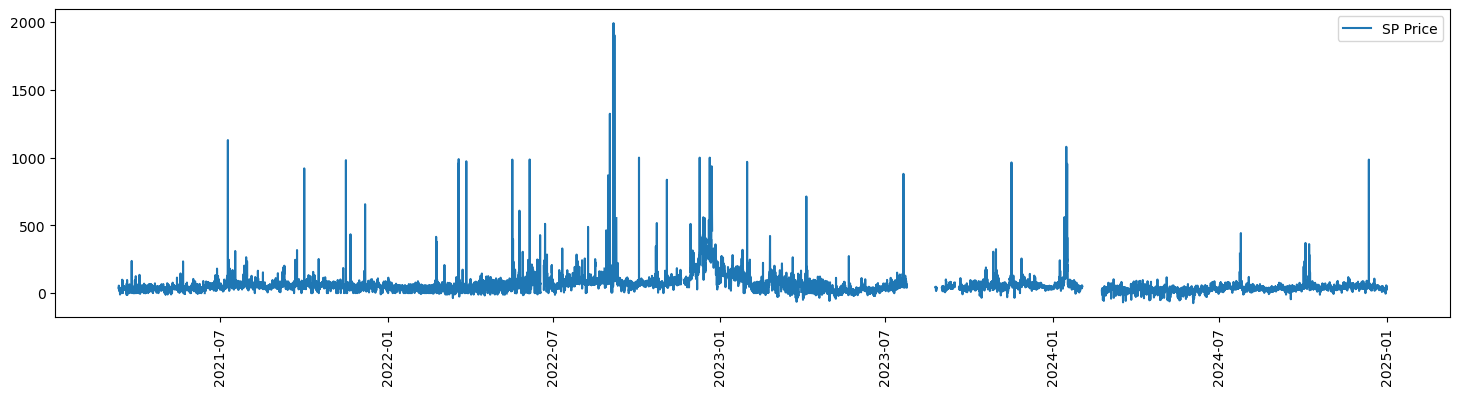

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from collections import defaultdict
from functools import reduce
from scipy.signal import find_peaks

data['begin_time'] = pd.to_datetime(data['begin_time'])

time1 = datetime.datetime(2023, 1, 1, 0, 0, 0)
time2 = datetime.datetime(2023, 1, 7, 0, 0, 0)

filtered_data = data[filter_times(data, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(data['begin_time'], data['NP-15 LMP_rt'] , label='SP Price')
#plt.plot(data['begin_time'], data['NP-15 LMP_da'] , label='NP Price')


plt.xticks(rotation=90)
plt.legend()
plt.show()

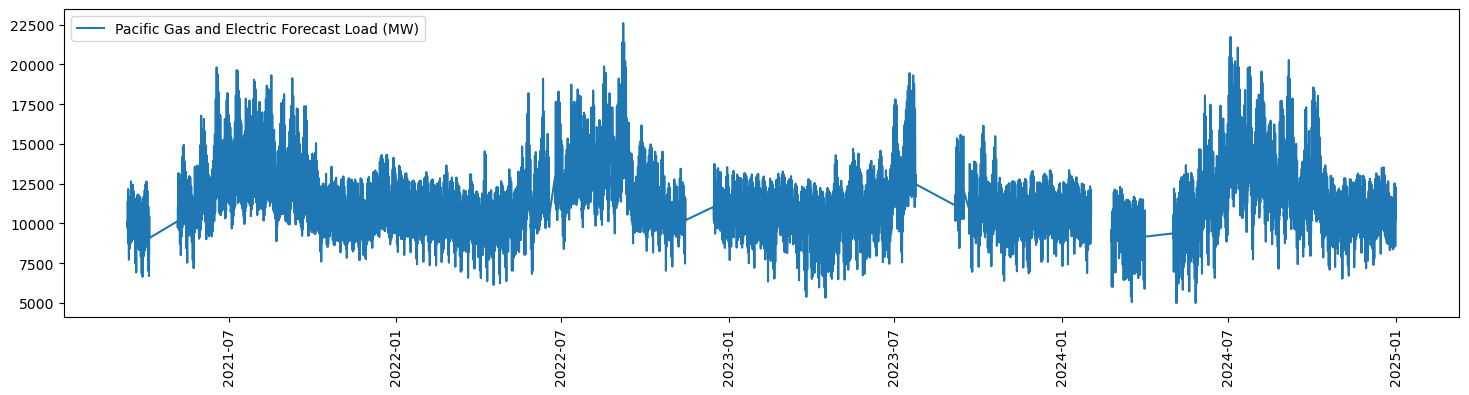

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from collections import defaultdict
from functools import reduce
from scipy.signal import find_peaks

data['begin_time'] = pd.to_datetime(data['begin_time'])


plt.figure(figsize=(18, 4))
plt.plot(data['begin_time'], data['Pacific Gas and Electric Forecast Load (MW)'] , label='Pacific Gas and Electric Forecast Load (MW)')


plt.xticks(rotation=90)
plt.legend()
plt.show()

In [ ]:
data[['Natural_gas_price', 'flow_klamath', 'flow_sacramento',
        'Pacific Gas and Electric Forecast Load (MW)',
       'Southern California Edison Forecast Load (MW)', 'solar_mw_NP15',
       'wind_mw_NP15', 'solar_mw_SP15', 'wind_mw_SP15']].corr()

#Separate NP and SP variables

,Natural_gas_price,flow_klamath,flow_sacramento,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW),solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15
Natural_gas_price,1.000000,0.208550,0.146296,-0.014097,-0.064674,-0.048991,-0.099272,-0.063088,-0.070702
flow_klamath,0.208550,1.000000,0.562717,-0.209778,-0.272598,-0.120827,-0.176300,-0.083986,0.036255
flow_sacramento,0.146296,0.562717,1.000000,-0.060040,-0.045599,-0.009338,-0.159697,0.015987,-0.075097
Pacific Gas and Electric Forecast Load (MW),-0.014097,-0.209778,-0.060040,1.000000,0.856653,-0.097281,0.299991,-0.138073,0.069533
Southern California Edison Forecast Load (MW),-0.064674,-0.272598,-0.045599,0.856653,1.000000,0.204616,0.224964,0.160755,0.005645
solar_mw_NP15,-0.048991,-0.120827,-0.009338,-0.097281,0.204616,1.000000,-0.249807,0.982760,-0.196831
wind_mw_NP15,-0.099272,-0.176300,-0.159697,0.299991,0.224964,-0.249807,1.000000,-0.285276,0.543145
solar_mw_SP15,-0.063088,-0.083986,0.015987,-0.138073,0.160755,0.982760,-0.285276,1.000000,-0.222060
wind_mw_SP15,-0.070702,0.036255,-0.075097,0.069533,0.005645,-0.196831,0.543145,-0.222060,1.000000


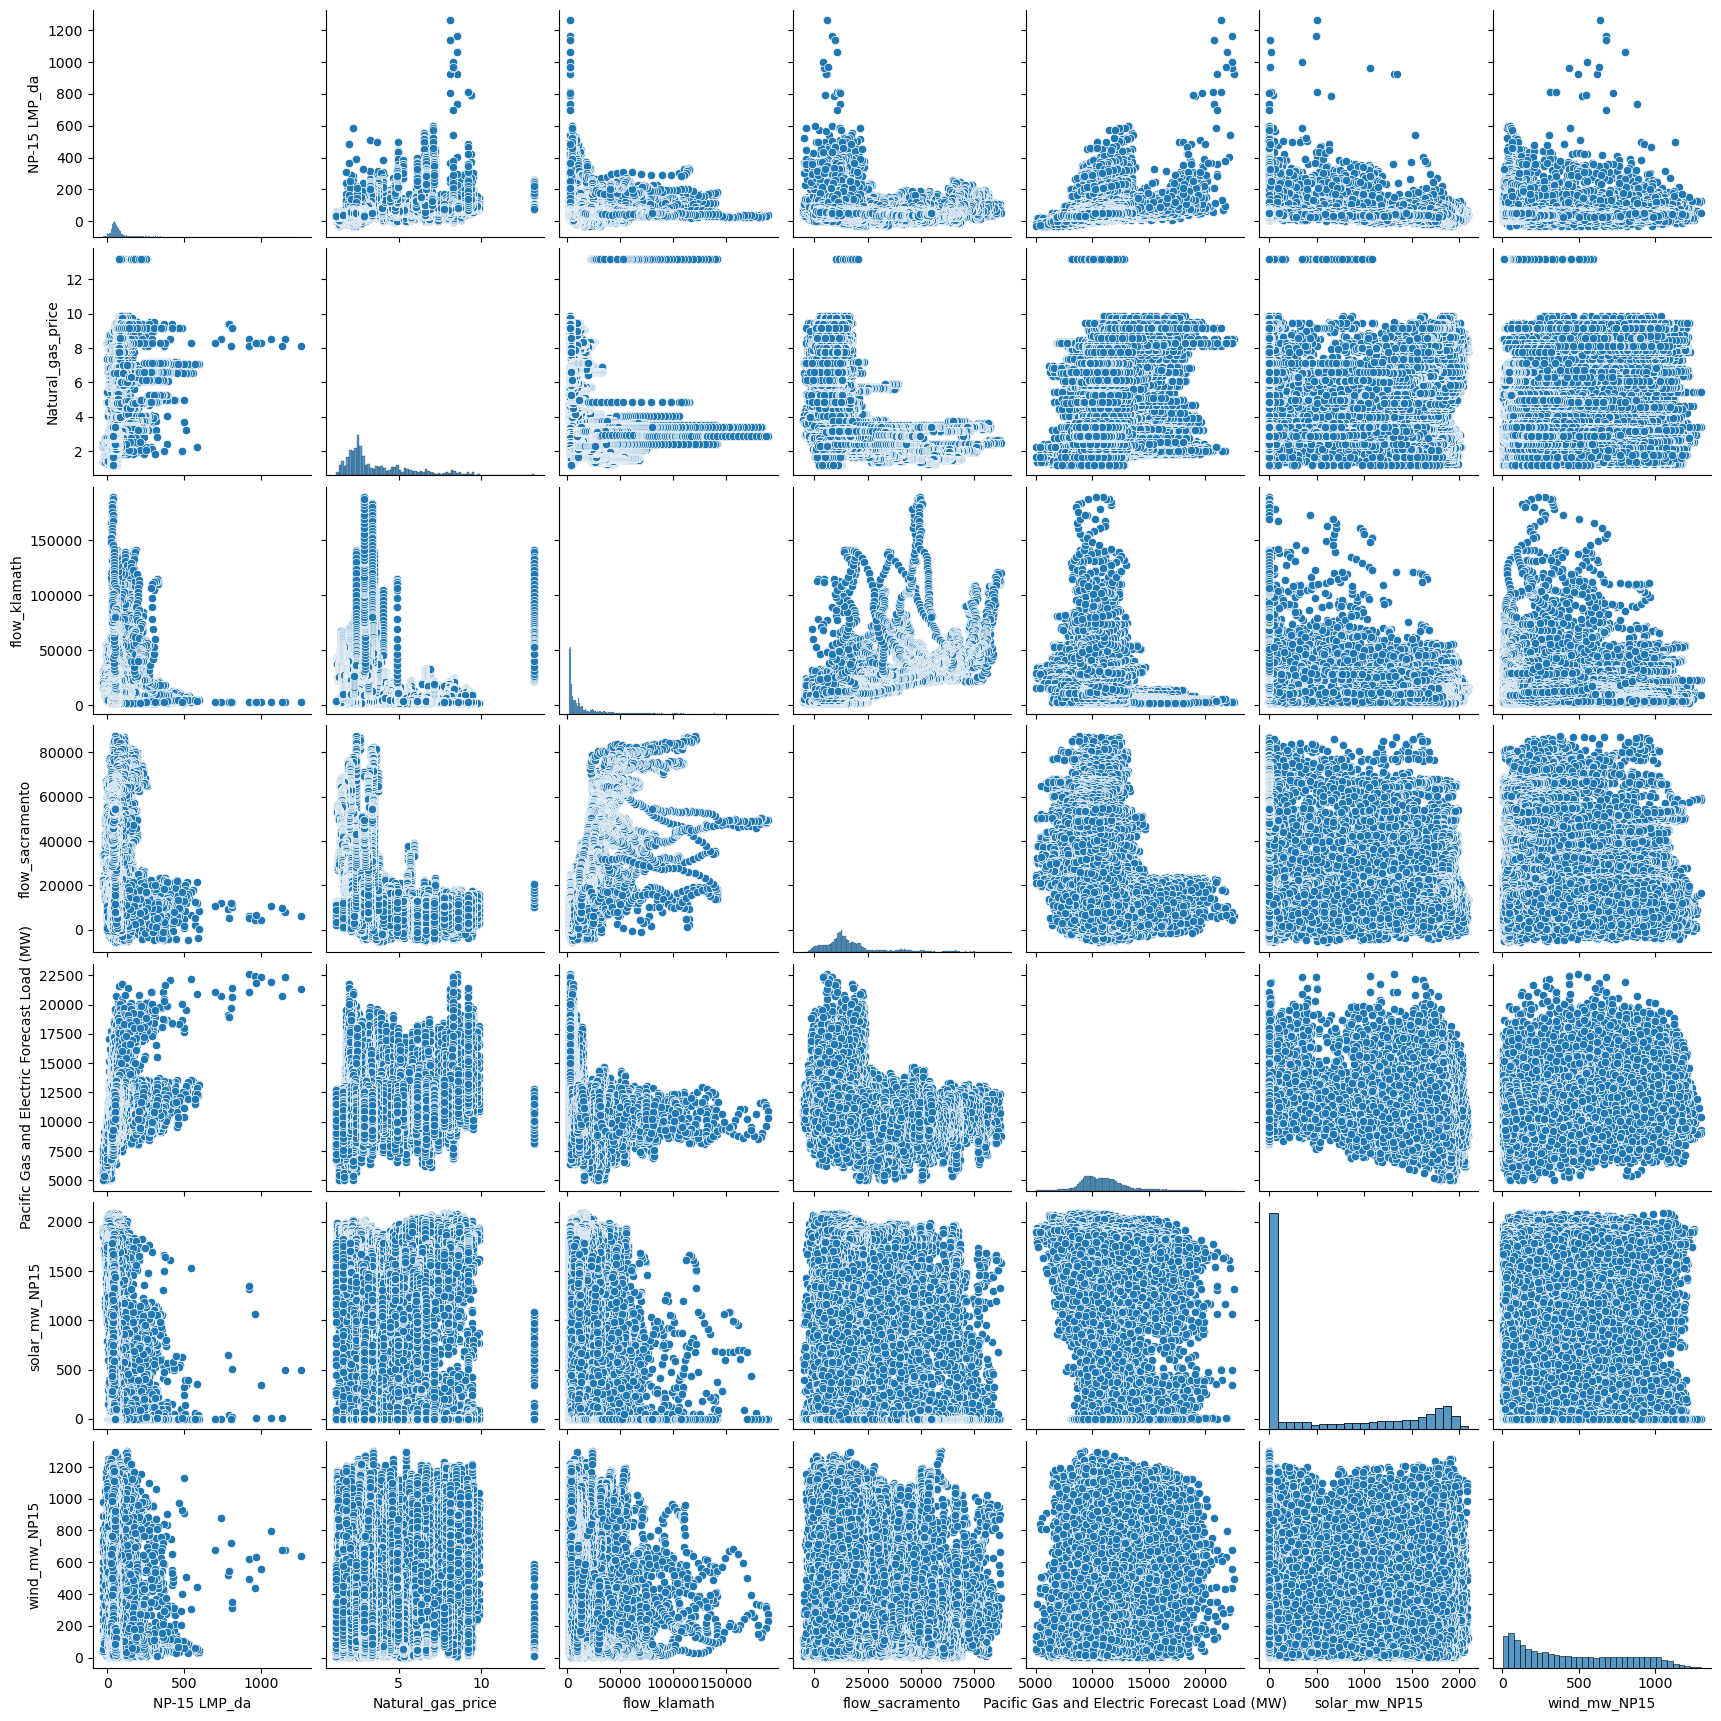

In [8]:
import seaborn as sns

sns.pairplot(data[['NP-15 LMP_da','Natural_gas_price', 'flow_klamath', 'flow_sacramento',
        'Pacific Gas and Electric Forecast Load (MW)', 'solar_mw_NP15',
       'wind_mw_NP15']])